# 2일차 실습 P9 — 하나만 바꿔 다시

- 끝 조건: 확인 셀 통과 + 기록 칸에 자기 말로 한 문장 — 무엇 하나를 바꾸고 무엇을 그대로 두었나
- **맨 위 준비 셀부터** 위에서 아래로 실행
- 셀 실행: 셀을 누르고 **Shift + Enter** 또는 셀 왼쪽 ▶
- Colab 에서 처음 열 때 경고 창이 뜨면 '계속' · 데이터는 내려받지 않음 · 준비 셀 · 문서 셀이 연습용 합성 문서를 만듦
- 학습 셀(기준 · 반복 실행의 흔들림 · 내 실험)은 에폭마다 loss 한 줄씩 찍힘 · `학습 끝` 줄이 찍힐 때까지 기다림
- 이 실습에는 빈칸 `____` 이 없음 · P9-1 셀에서 **요인 하나의 값만** 바꿈 · 바꾼 뒤 **그 셀부터 다시 실행**
- 막히면 `[안내]` 문장 → **에러 칸 맨 아래 줄** → 힌트 순서로 읽음
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것

## 에러를 읽는 법

- 에러 칸 첫 줄(`...Error    Traceback ...`)은 제목일 뿐 · 무엇이 틀렸는지는 **맨 아래 줄**
- 중간의 `---->` 화살표 줄 · torch 안쪽 칸은 처음엔 건너뜀 · **위에 찍힌 `[안내]` 문장과 맨 아래 줄부터** 읽음

| 맨 아래 줄에 보이는 말 | 뜻 | 먼저 볼 곳 |
|---|---|---|
| `name 'run_setting' is not defined` | 짝 · 함수 셀을 안 돌렸거나 런타임이 끊김 | 준비 셀부터 순서대로 다시 |
| `name 'base_model' is not defined` | 기준 결과 셀을 안 돌림 | 기준 결과 셀 |
| `invalid syntax. Perhaps you forgot a comma?` | 괄호 안 두 수 사이 쉼표가 빠짐 | P9-1 의 `CH` 줄 |

- **에러가 없는데** 확인 셀이 `[안내]` 를 찍으면 → 그 문장이 가리키는 줄부터
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것
- 아래 셀 맨 아래 줄이 `AssertionError: [안내] 확인 셀에서 …` → 확인 셀을 먼저 · P9-1 셀을 다시 실행했으면 확인 셀도 다시

## 준비

합성 문서 만들기 · 조각 자르기 · 모델 · 학습 함수 · 그림 함수 · 고치지 않고 실행

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

plt.rcParams.update({"figure.facecolor": "#1A222C", "axes.facecolor": "#1A222C", "savefig.facecolor": "#1A222C",   # 그림을 어두운 화면에 맞춤
                     "text.color": "#EEF2F6", "axes.labelcolor": "#EEF2F6", "xtick.color": "#EEF2F6", "ytick.color": "#EEF2F6", "axes.edgecolor": "#5C6A78"})

# ── 합성 문서 만들기 · 고치지 않고 실행 · 읽지 않아도 됨 ──
WORDS = ("the of and to in is was for on that with as by at from this be are or an report data model image paper result "
         "note page table value error clean noise sample layer filter record method letter number office meeting account "
         "review summary budget project quality section figure total").split()


def make_doc(seed, h=128, w=256, kinds=("gradient", "occlude", "saltpepper")):
    """문서 번호 하나 → (clean, dirty) · 값 0~1 · 같은 번호는 늘 같은 문서"""
    rng = np.random.default_rng(seed)
    size = int(rng.integers(12, 20))
    img = Image.new("L", (w, h), 255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default(size=size)
    y = int(rng.integers(2, max(3, size // 2)))
    while y + int(size * 1.45) <= h - 2:                      # 줄마다 단어를 이어 씀
        x, words = int(rng.integers(2, 12)), []
        while True:
            cand = " ".join(words + [WORDS[int(rng.integers(len(WORDS)))]])
            if x + draw.textlength(cand, font=font) > w - 4:
                break
            words = cand.split()
        if words:
            draw.text((x, y), " ".join(words), fill=0, font=font)
        y += int(size * 1.45)
    clean = np.asarray(img, dtype=np.float32) / 255.0
    d = clean.copy()
    if "gradient" in kinds:                                   # 한쪽으로 갈수록 어두워짐
        g = np.linspace(0, rng.uniform(0.1, 0.35), w, dtype=np.float32)[None, :]
        if rng.random() < 0.5:
            g = g[:, ::-1]
        d = d * (1 - g)
    if "occlude" in kinds:                                    # 회색 상자가 글자를 가림
        oh, ow = int(h * rng.uniform(0.1, 0.25)), int(w * rng.uniform(0.05, 0.15))
        oy, ox = int(rng.integers(0, h - oh)), int(rng.integers(0, w - ow))
        d[oy:oy + oh, ox:ox + ow] = rng.uniform(0.2, 0.6)
    if "saltpepper" in kinds:                                 # 검은 점 · 흰 점
        m = rng.random(d.shape)
        p = rng.uniform(0.002, 0.01)
        d[m < p / 2] = 0.0
        d[m > 1 - p / 2] = 1.0
    return clean, np.clip(d, 0, 1).astype(np.float32)


# ── 오늘 쓰는 크기 · 문서 번호 · 도구 ──
H, W, PS = 128, 256, 48                 # 문서 세로 · 가로 · 조각 한 변
train_ids = list(range(1000, 1024))     # 학습 문서 24장
eval_ids = list(range(2000, 2008))      # 평가 문서 8장 · 학습에 쓰지 않음


def crop(img, y, x):                    # (y, x) 를 왼쪽 위 모서리로 삼아 48×48 조각을 잘라 냄
    return img[y:y + PS, x:x + PS]


def to_batch(patches):                  # 조각 목록 → (조각 수, 1, 48, 48) 텐서
    return torch.tensor(np.stack(patches)).unsqueeze(1)


def make_model():                       # 1일차 Conv 오토인코더와 같은 구성 · 48 → 24 → 12 → 24 → 48
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(),
        nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
        nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1), nn.ReLU(),
        nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1), nn.Sigmoid())


def train(X, Y, name, epochs=10):       # 입력 X · 정답 Y 로 학습 · 에폭마다 loss 한 줄
    torch.manual_seed(0)                # 모델마다 같은 출발점
    model = make_model()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    t = time.time()
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(len(X))
        total = 0.0
        for k in range(0, len(X), 32):
            b = perm[k:k + 32]
            opt.zero_grad()
            loss = F.mse_loss(model(X[b]), Y[b])
            loss.backward()
            opt.step()
            total += loss.item() * len(b)
        print(f"{name}  에폭 {epoch:>2}  loss {total / len(X):.4f}")
    print(f"{name}  학습 끝 ({time.time() - t:.0f}초)")
    return model


def show_rows(rows, idx):               # rows = [(줄 이름, 조각 묶음), …] · 줄마다 같은 번호의 조각
    fig, axes = plt.subplots(len(rows), len(idx), figsize=(len(idx), 1.25 * len(rows)))
    for r, (name, T) in enumerate(rows):
        for c, j in enumerate(idx):
            axes[r, c].imshow(T[j, 0], cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_title(name, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

## 문서

학습 문서 24장 · 평가 문서 8장 · 문서 1000 한 쌍 그림 · 고치지 않고 실행

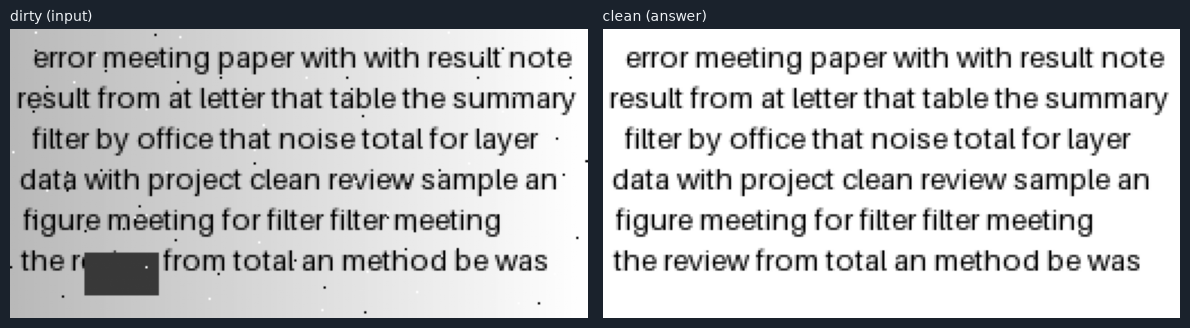

문서 32 장 · 한 장 크기 (128, 256)


In [2]:
docs = {i: make_doc(i) for i in train_ids + eval_ids}   # 문서 번호 → (clean, dirty)
clean, dirty = docs[1000]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, (name, img) in zip(axes, [("dirty (input)", dirty), ("clean (answer)", clean)]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(name, loc="left", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("문서", len(docs), "장 · 한 장 크기", clean.shape)

## 짝 · 설정 하나로 학습하는 함수 · 평가 함수

- P6 과 같은 짝 · `run_setting(이름, 에폭, 채널, 시드)` 설정 하나로 학습 · 짝 · 묶음 크기 · 학습률은 늘 같음
- `evaluate(모델)` 평가 문서 8장을 통째로 넣어 (문서 전체 RMSE, 글자 칸 RMSE) · 글자 칸 = 정답에서 0.5 보다 어두운 칸 · 고치지 않고 실행

In [5]:
# 짝 · 설정 하나로 학습하는 함수 · 평가 함수 — 고치지 않고 실행
rng = np.random.default_rng(2026)                # P6 과 같은 짝 · 학습 문서 24장 · 문서마다 좌표 128개
X, Y_A = [], []
for i in train_ids:
    c, d = docs[i]
    ys, xs = rng.integers(0, H - PS + 1, 128), rng.integers(0, W - PS + 1, 128)
    for y, x in zip(ys, xs):
        X.append(crop(d, y, x))
        Y_A.append(crop(c, y, x))
X, Y_A = to_batch(X), to_batch(Y_A)


def make_model_ch(ch):                           # 채널 두 수 ch = (첫 층, 둘째 층) · 나머지는 준비 셀 make_model 과 같음
    c1, c2 = ch
    return nn.Sequential(
        nn.Conv2d(1, c1, 3, 2, 1), nn.ReLU(),
        nn.Conv2d(c1, c2, 3, 2, 1), nn.ReLU(),
        nn.ConvTranspose2d(c2, c1, 3, 2, 1, output_padding=1), nn.ReLU(),
        nn.ConvTranspose2d(c1, 1, 3, 2, 1, output_padding=1), nn.Sigmoid())


def run_setting(name, epochs, ch, seed=0):       # 설정 하나로 학습 · 에폭마다 loss 한 줄
    torch.manual_seed(seed)
    model = make_model_ch(ch)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(len(X))
        total = 0.0
        for k in range(0, len(X), 32):
            b = perm[k:k + 32]
            opt.zero_grad()
            loss = F.mse_loss(model(X[b]), Y_A[b])
            loss.backward()
            opt.step()
            total += loss.item() * len(b)
        print(f"{name}  에폭 {epoch:>2}  loss {total / len(X):.4f}")
    print(f"{name}  학습 끝")
    return model.eval()


def rmse_doc(outs, cleans):                   # 문서마다 RMSE → 평균
    return float(np.mean([np.sqrt(((np.asarray(o) - np.asarray(c)) ** 2).mean()) for o, c in zip(outs, cleans)]))


def rmse_text(outs, cleans):                     # 문서마다 글자 칸(정답에서 0.5 보다 어두운 칸)만 RMSE → 평균
    return float(np.mean([np.sqrt(((np.asarray(o) - c)[c < 0.5] ** 2).mean()) for o, c in zip(outs, cleans)]))


eval_clean = [docs[i][0] for i in eval_ids]


def evaluate(model):                             # 평가 문서 8장을 통째로 → (문서 전체 RMSE, 글자 칸 RMSE)
    with torch.no_grad():
        outs = [model(torch.tensor(docs[i][1])[None, None])[0, 0].numpy() for i in eval_ids]
    return rmse_doc(outs, eval_clean), rmse_text(outs, eval_clean)


print("학습 조각", tuple(X.shape), "· 평가 문서", len(eval_clean), "장")

학습 조각 (3072, 1, 48, 48) · 평가 문서 8 장


## 기준 결과

채널 (16, 32) · 에폭 10 · 시드 0 · P6 맞춘 짝과 같은 설정 · 고치지 않고 실행 · `기준  학습 끝` 줄까지 기다림

In [4]:
# 기준 결과 — 채널 (16, 32) · 에폭 10 · 시드 0 · 고치지 않고 실행
base_model = run_setting("기준", 10, (16, 32), seed=0)
기준 = evaluate(base_model)
print(f"기준 채널 (16, 32) · 에폭 10 · 시드 0   문서 전체 RMSE {기준[0]:.3f}   글자 칸 RMSE {기준[1]:.3f}   (평가 문서 8장 · 문서별 평균)")

기준  에폭  1  loss 0.1025
기준  에폭  2  loss 0.0512
기준  에폭  3  loss 0.0276
기준  에폭  4  loss 0.0175
기준  에폭  5  loss 0.0131
기준  에폭  6  loss 0.0107
기준  에폭  7  loss 0.0093
기준  에폭  8  loss 0.0084
기준  에폭  9  loss 0.0077
기준  에폭 10  loss 0.0073
기준  학습 끝
기준 채널 (16, 32) · 에폭 10 · 시드 0   문서 전체 RMSE 0.069   글자 칸 RMSE 0.156   (평가 문서 8장 · 문서별 평균)


## (선택) 반복 실행의 흔들림 — 설정은 그대로 · 시드만 1

설정을 바꾸지 않고 다시 실행해도 숫자가 얼마나 달라지는지 봄 · 건너뛰어도 뒤 셀은 돎(결과 표에 흔들림 줄이 빠짐)

In [6]:
# (선택) 반복 실행의 흔들림 — 기준 설정 그대로 · 시드만 1
기준_시드1 = evaluate(run_setting("기준 시드 1", 10, (16, 32), seed=1))
print(f"기준 시드 1   문서 전체 RMSE {기준_시드1[0]:.3f}   글자 칸 RMSE {기준_시드1[1]:.3f}   (평가 문서 8장 · 문서별 평균)")
print(f"반복 실행의 흔들림(시드 0 ↔ 1)   문서 전체 {abs(기준_시드1[0] - 기준[0]):.3f}   글자 칸 {abs(기준_시드1[1] - 기준[1]):.3f}")

기준 시드 1  에폭  1  loss 0.1019
기준 시드 1  에폭  2  loss 0.0496
기준 시드 1  에폭  3  loss 0.0265
기준 시드 1  에폭  4  loss 0.0167
기준 시드 1  에폭  5  loss 0.0120
기준 시드 1  에폭  6  loss 0.0101
기준 시드 1  에폭  7  loss 0.0090
기준 시드 1  에폭  8  loss 0.0083
기준 시드 1  에폭  9  loss 0.0078
기준 시드 1  에폭 10  loss 0.0074
기준 시드 1  학습 끝
기준 시드 1   문서 전체 RMSE 0.070   글자 칸 RMSE 0.160   (평가 문서 8장 · 문서별 평균)
반복 실행의 흔들림(시드 0 ↔ 1)   문서 전체 0.001   글자 칸 0.004


## 기록 ①–③ — 실행 전에 적음 (채점 아님)

이 칸을 두 번 눌러 `→` 뒤에 적음 · 요인 A: 에폭 수 10 → 20 · 요인 B: 채널 (16, 32) → (8, 16) · 둘 가운데 **하나만**

1. ① 무엇을 바꾸나(A 또는 B) · 왜 → 
    - A: 학습을 더 시켜서 loss를 줄여보자. 
2. ② 예상(문서 전체 · 글자 칸 · 그림) →
    - A: 문서 전체, 글자 칸 로스 작아지고, 그림이 더 깨끗해질 것이다. 
3. ③ 그대로 두는 것 →

## P9-1. 바꾸는 요인 하나

- 요인 A = 에폭 수 `EPOCHS` · 요인 B = 채널 `CH`(두 수가 한 요인)
- 후보: A 는 `10` → `20` · B 는 `(16, 32)` → `(8, 16)`
- 요인 A 를 고르면 수업 시연(에폭 20)과 다른 값 권장 · 예: 5 · 15 · 30

1. 기록 ① 에 적은 요인의 줄만 값을 바꿈 · 다른 줄은 그대로
2. 실행 → 내 설정 한 줄 → 아래 **확인** 셀 실행 → `설정 확인 통과` 가 나오면 P9-2 로 · **P9-1 셀을 다시 실행했으면 확인 셀도 다시**
- 확인 셀이 `[안내]` 를 찍으면 그 문장부터 읽음 · 막히면 코드 셀 아래 **힌트 1** → **힌트 2** 순서로 하나씩 펼침
- 그래도 막히면 확인 셀 아래 **대체 셀**을 실행하고 P9-2 의 그림 셀로

In [27]:
# 문법 예시 (이 실습의 답 아님)
#   size = 5          → 따옴표 없는 정수 하나
#   pair = (3, 6)     → 괄호 안 정수 두 개 · 쉼표로 나눔

EPOCHS = CH = my_model = 내결과 = None        # 이 셀을 실행할 때마다 이전 결과를 지움 · 고치지 않음
설정_통과 = 대체_사용 = False                  # 확인 셀 통과 표시 · 대체 셀 사용 표시 · 고치지 않음

EPOCHS = 10                                  # 요인 A · 에폭 수 · 기준 10
CH = (8, 16)                                # 요인 B · 채널 두 수(두 수가 한 요인) · 기준 (16, 32)
print("내 설정 · 에폭", EPOCHS, "· 채널", CH)

내 설정 · 에폭 10 · 채널 (8, 16)


<details><summary><b>힌트 1</b> — 막힐 때만 펼침</summary>

- 에폭은 따옴표 없는 정수 하나 · 채널은 괄호 안 정수 두 개(쉼표로 나눔) · 바꾸지 않을 줄은 기준 값 그대로

</details>

<details><summary><b>힌트 2</b> — 힌트 1 로도 막힐 때</summary>

- A: `EPOCHS = 20` · B: `CH = (8, 16)` · 둘 가운데 한 줄만

</details>

In [28]:
# P9-1 확인 — 바꾼 요인 검사 · 고치지 않고 실행만 · 읽지 않아도 됨
# 약속(수업 설명과 같음): 기준 = 에폭 10 · 채널 (16, 32) · 요인 두 개(A 에폭 · B 채널) 가운데 하나만 바꿈 · 채널 두 수는 한 요인 · (32, 64) 는 쓰지 않음
def 과제_문법_검사(*표시):                       # 과제 셀을 마지막으로 실행한 글자에 문법 오류가 있었는지 · 실행 기록(In)이 없으면 통과하지 않음
    기록 = globals().get("In")
    if not isinstance(기록, list) or len(기록) < 2:
        return False
    for 표 in 표시:
        for src in reversed(기록[:-1]):
            if 표 in src and "def 과제_문법_검사" not in src:
                try:
                    compile(src, "<과제 셀>", "exec")
                except SyntaxError:
                    return False
                break
    return True


def 설정_검사(EPOCHS, CH):
    if EPOCHS is None or CH is None:
        return "[안내] 위 P9-1 셀이 끝까지 실행되지 않았음 → P9-1 셀부터 다시 실행"
    if isinstance(EPOCHS, bool) or not isinstance(EPOCHS, int):
        return "[안내] EPOCHS 는 따옴표 없는 정수 하나"
    if not 1 <= EPOCHS <= 40:
        return "[안내] EPOCHS 는 1~40 사이 정수"
    if not isinstance(CH, (tuple, list)) or len(CH) != 2 or any(isinstance(c, bool) or not isinstance(c, int) for c in CH):
        return "[안내] CH 는 괄호 안 정수 두 개"
    if tuple(CH) == (32, 64):
        return "[안내] 채널 (32, 64) 는 이 실습에서 쓰지 않음 → 다른 두 수"
    if not all(1 <= c <= 32 for c in CH):
        return "[안내] CH 의 두 수는 각각 1~32 사이 정수"
    바뀐_요인 = int(EPOCHS != 10) + int(tuple(CH) != (16, 32))
    if 바뀐_요인 == 0:
        return "[안내] 아무것도 바꾸지 않았음 → 요인 하나(EPOCHS 줄 또는 CH 줄)의 값만 바꿈"
    if 바뀐_요인 == 2:
        return "[안내] 에폭과 채널 두 요인을 함께 바꿨음 → 달라진 결과가 어느 요인 때문인지 알 수 없음 · 요인 하나만 바꿈"
    return "설정 확인 통과"


결과 = 설정_검사(globals().get("EPOCHS"), globals().get("CH")) if 과제_문법_검사('EPOCHS = CH = my_model = 내결과 = None') else "[안내] 과제 셀의 정상 실행을 확인할 수 없음(문법 오류 또는 실행 기록 없음) · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행 · 계속되면 런타임을 다시 시작하고 준비부터 실행"
설정_통과 = 결과 == "설정 확인 통과"              # 통과를 찍을 때만 True · 내 실험 셀이 이 값을 봄
설정_출처 = "대체 셀" if globals().get("대체_사용") else "직접 바꿈"
print(결과)

설정 확인 통과


### 대체 셀 — 확인 셀이 `[안내]` 를 찍었고 막혔을 때만 실행

- P9-1 에서 바꾼 요인을 보고 정해진 설정으로 내 실험을 학습 · 평가함 · 에폭을 바꿨으면 경로 A(에폭 20) · 채널을 바꿨으면 경로 B(채널 (8, 16))
- 어느 요인인지 알 수 없으면 경로 B 를 쓰고 `대체 경로 B 사용 · 기록 ①도 B로` 를 찍음 → 기록 ① 을 B 로 고침
- 실행하면 P9-2 의 **내 실험** 셀은 건너뛰고 **그림** 셀부터 실행 · 결과 표 첫 줄에 `설정: 대체 셀 · 경로 …` 가 찍힘

In [14]:
# 대체 셀 — 막혔을 때만 · P9-1 에서 바꾼 요인을 따라 정해진 설정으로 내 실험을 학습 · 평가
def 바꾼_요인():
    e, ch = globals().get("EPOCHS"), globals().get("CH")
    에폭 = e is not None and e != 10
    try:
        채널 = ch is not None and tuple(ch) != (16, 32)
    except TypeError:
        채널 = True
    return "A" if 에폭 and not 채널 else "B" if 채널 and not 에폭 else None


경로 = 바꾼_요인()
if 경로 is None:
    경로 = "B"
    print("대체 경로 B 사용 · 기록 ①도 B로")
EPOCHS, CH = (20, (16, 32)) if 경로 == "A" else (10, (8, 16))
print(f"대체 셀 · 경로 {경로} · 에폭 {EPOCHS} · 채널 {CH}")
my_model = run_setting(f"대체 경로 {경로}", EPOCHS, CH, seed=0)
내결과 = evaluate(my_model)
print(f"대체 셀 · 경로 {경로}   문서 전체 RMSE {내결과[0]:.3f}   글자 칸 RMSE {내결과[1]:.3f}   (평가 문서 8장 · 문서별 평균)")
설정_통과, 대체_사용, 설정_출처 = True, True, f"대체 셀 · 경로 {경로}"   # 대체 셀 결과라는 표시 · P9-1 셀을 다시 실행하면 지워짐

대체 셀 · 경로 B · 에폭 10 · 채널 (8, 16)
대체 경로 B  에폭  1  loss 0.1655
대체 경로 B  에폭  2  loss 0.0891
대체 경로 B  에폭  3  loss 0.0765
대체 경로 B  에폭  4  loss 0.0558
대체 경로 B  에폭  5  loss 0.0420
대체 경로 B  에폭  6  loss 0.0349
대체 경로 B  에폭  7  loss 0.0308
대체 경로 B  에폭  8  loss 0.0272
대체 경로 B  에폭  9  loss 0.0238
대체 경로 B  에폭 10  loss 0.0208
대체 경로 B  학습 끝
대체 셀 · 경로 B   문서 전체 RMSE 0.123   글자 칸 RMSE 0.284   (평가 문서 8장 · 문서별 평균)


## P9-2. 내 실험 · 그림 · 표

아래 세 셀은 **고치지 않고** 차례로 실행 · 확인 셀 통과 뒤에만 돎(대체 셀을 썼으면 내 실험 셀은 건너뜀)

1. **내 실험**: P9-1 설정 · 시드 0 · 같은 짝 · 같은 평가 문서 8장 · 에폭마다 loss 한 줄 · 첫 줄에 설정 출처
2. **그림**: 평가 문서 2000 의 같은 부분 확대 · dirty · clean · 기준 · 내 실험
3. **표**: 기준 · 내 실험 · 차이 · (선택) 반복 실행의 흔들림 · 문서 전체 · 글자 칸
- 좋아져도 나빠져도 결과임 · 표의 '반복 실행의 흔들림' 줄: 같은 설정을 다시 실행해도 이번 두 실행에서 이만큼 달랐음 · 이와 비슷한 작은 차이 하나만으로는 바꾼 설정의 효과라고 확신하기 어려움 · 그림 → 숫자 순서로 읽고 기록 ④–⑦ 로

In [29]:
# 내 실험 — P9-1 설정 · 시드 0 · 같은 짝 · 같은 평가 · 확인 셀 통과 뒤에만
assert globals().get("설정_통과"), "[안내] 확인 셀에서 '설정 확인 통과' 를 받은 뒤 실행 · P9-1 셀을 다시 실행했으면 확인 셀도 다시 · 막히면 대체 셀"
print("설정:", 설정_출처, "· 에폭", EPOCHS, "· 채널", tuple(CH))
my_model = run_setting("내 실험", EPOCHS, tuple(CH), seed=0)
내결과 = evaluate(my_model)
print(f"내 실험 채널 {tuple(CH)} · 에폭 {EPOCHS} · 시드 0   문서 전체 RMSE {내결과[0]:.3f}   글자 칸 RMSE {내결과[1]:.3f}   (평가 문서 8장 · 문서별 평균)")

설정: 직접 바꿈 · 에폭 10 · 채널 (8, 16)
내 실험  에폭  1  loss 0.1655
내 실험  에폭  2  loss 0.0891
내 실험  에폭  3  loss 0.0765
내 실험  에폭  4  loss 0.0558
내 실험  에폭  5  loss 0.0420
내 실험  에폭  6  loss 0.0349
내 실험  에폭  7  loss 0.0308
내 실험  에폭  8  loss 0.0272
내 실험  에폭  9  loss 0.0238
내 실험  에폭 10  loss 0.0208
내 실험  학습 끝
내 실험 채널 (8, 16) · 에폭 10 · 시드 0   문서 전체 RMSE 0.123   글자 칸 RMSE 0.284   (평가 문서 8장 · 문서별 평균)


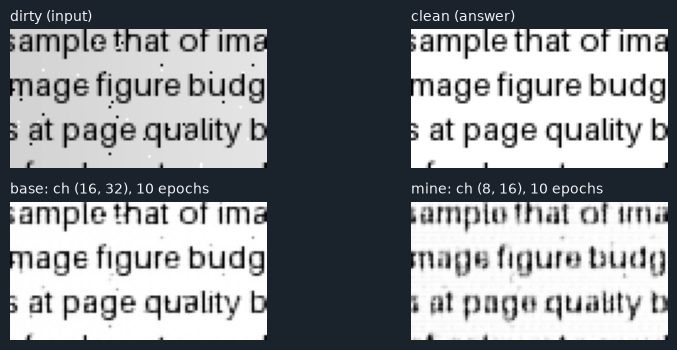

In [30]:
# 그림 — 평가 문서 2000 의 같은 부분 확대 · dirty · clean · 기준 · 내 실험
assert globals().get("설정_통과") and globals().get("my_model") is not None, "[안내] 확인 셀 통과 뒤 내 실험 셀(또는 대체 셀)까지 실행한 다음 실행 · P9-1 셀을 다시 실행했으면 확인 셀부터 다시"
c, d = docs[2000]
with torch.no_grad():
    base_img = base_model(torch.tensor(d)[None, None])[0, 0].numpy()
    my_img = my_model(torch.tensor(d)[None, None])[0, 0].numpy()
zy, zx = slice(8, 64), slice(8, 112)            # 문서 왼쪽 위 글자 부분
fig, axes = plt.subplots(2, 2, figsize=(9, 3.6))
for ax, (name, img) in zip(axes.flat, [("dirty (input)", d), ("clean (answer)", c), ("base: ch (16, 32), 10 epochs", base_img), (f"mine: ch {tuple(CH)}, {EPOCHS} epochs", my_img)]):
    ax.imshow(img[zy, zx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(name, loc="left", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [31]:
# 결과 표 — 같은 평가(평가 문서 8장 · 문서별 RMSE 평균) · 작을수록 정답에 가까움
assert globals().get("설정_통과") and globals().get("내결과") is not None, "[안내] 확인 셀 통과 뒤 내 실험 셀(또는 대체 셀)까지 실행한 다음 실행 · P9-1 셀을 다시 실행했으면 확인 셀부터 다시"
print("설정:", 설정_출처)
print(f"기준     채널 (16, 32) · 에폭 10          문서 전체 {기준[0]:.3f}   글자 칸 {기준[1]:.3f}")
print(f"내 실험  채널 {tuple(CH)} · 에폭 {EPOCHS}          문서 전체 {내결과[0]:.3f}   글자 칸 {내결과[1]:.3f}")
print(f"내 실험 − 기준                           문서 전체 {내결과[0] - 기준[0]:+.3f}   글자 칸 {내결과[1] - 기준[1]:+.3f}")
if globals().get("기준_시드1") is not None:
    print(f"반복 실행의 흔들림(시드 0 ↔ 1)            문서 전체 {abs(기준_시드1[0] - 기준[0]):.3f}   글자 칸 {abs(기준_시드1[1] - 기준[1]):.3f}")
    print("같은 설정을 다시 실행해도 이번 두 실행에서 이만큼 달랐음 · 이와 비슷한 작은 차이 하나만으로는 바꾼 설정의 효과라고 확신하기 어려움")
else:
    print("반복 실행의 흔들림: (선택) 흔들림 셀을 실행하지 않았음")
print("(평가 문서 8장 · 문서별 평균)")

설정: 직접 바꿈
기준     채널 (16, 32) · 에폭 10          문서 전체 0.069   글자 칸 0.156
내 실험  채널 (8, 16) · 에폭 10          문서 전체 0.123   글자 칸 0.284
내 실험 − 기준                           문서 전체 +0.054   글자 칸 +0.129
반복 실행의 흔들림(시드 0 ↔ 1)            문서 전체 0.001   글자 칸 0.004
같은 설정을 다시 실행해도 이번 두 실행에서 이만큼 달랐음 · 이와 비슷한 작은 차이 하나만으로는 바꾼 설정의 효과라고 확신하기 어려움
(평가 문서 8장 · 문서별 평균)


## 기록 ④–⑦ — 실행 뒤에 적음 (채점 아님)

이 칸을 두 번 눌러 `→` 뒤에 적음 · ④ 실행 · ⑤ 같은 평가는 위 셀들이 함

(필수) 무엇 하나를 바꾸고 무엇을 그대로 두었나 · 자기 말로 한 문장 →
5. ⑥ 결과 — 그림에서 본 것 한 줄 →
- A: epoch=20, channel=(16,32)


| epoch | Loss |
| --- | --- |
| 1 | 0.1025 |
| 2 | 0.0512 |
| 3 | 0.0276 |
| 4 | 0.0175 |
| 5 | 0.0131 |
| 6 | 0.0107 |
| 7 | 0.0093 |
| 8 | 0.0084 |
| 9 | 0.0077 |
| 10 | 0.0073 |
| 11 | 0.0069 |
| 12 | 0.0066 |
| 13 | 0.0064 |
| 14 | 0.0062 |
| 15 | 0.0061 |
| 16 | 0.0060 |
| 17 | 0.0058 |
| 18 | 0.0057 |
| 19 | 0.0056 |
| 20 | 0.0055 |

| 지표 | 값 |
| --- | --- |
| 문서 전체 RMSE | 0.061 |
| 글자 칸 RMSE | 0.136 |
| 평가 문서 수 | 8 |
        

- B: epoch=10, channel=(8,16)

| 에폭 | Loss |
| --- | --- |
| 1 | 0.1655 |
| 2 | 0.0891 |
| 3 | 0.0765 |
| 4 | 0.0558 |
| 5 | 0.0420 |
| 6 | 0.0349 |
| 7 | 0.0308 |
| 8 | 0.0272 |
| 9 | 0.0238 |
| 10 | 0.0208 |

| 지표 | 값 |
| --- | --- |
| 문서 전체 RMSE | 0.123 |
| 글자 칸 RMSE | 0.284 |
| 평가 문서 수 | 8 |

6. ⑥ 결과 — 숫자 한 줄(반복 실행의 흔들림과 나란히) →
    - A:
        - 기준(문서 전체, 글자 칸): 0.069, 0.156
        - 실험(문서 전체, 글자 칸): 0.061, 0.136
    - B: 
        - 기준(문서 전체, 글자 칸): 0.069, 0.156
        - 실험(문서 전체, 글자 칸): 0.123, 0.284
7. ⑦ 다음 판단 · 나빠졌다면 무엇을 알게 됐나 →
    - retention dimension을 줄이는 건 모델 성능을 떨어뜨릴 수 있다! epoch을 늘리면 성능을 높일 수 있다!
대체 셀을 썼나 · 썼다면 어느 경로 →